In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
from re import X
mnist=keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train,x_test=x_train/255.0,x_test/255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


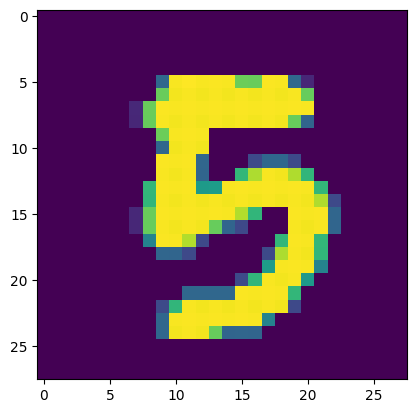

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[244])


In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
model=keras.Sequential([
    layers.Flatten(input_shape=(28,28,1)),#input layer
    layers.Dense(128,activation='relu'),#hidden layers 128 based on accuracy to give and to change 2 power
    layers.Dense(10,activation='sigmoid')  #outputlayer
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.fit(x_train,y_train,validation_split=0.1,epochs=17)

Epoch 1/17
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9209 - loss: 0.2758 - val_accuracy: 0.9642 - val_loss: 0.1333
Epoch 2/17
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9640 - loss: 0.1227 - val_accuracy: 0.9705 - val_loss: 0.1054
Epoch 3/17
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9744 - loss: 0.0851 - val_accuracy: 0.9732 - val_loss: 0.0896
Epoch 4/17
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9807 - loss: 0.0636 - val_accuracy: 0.9765 - val_loss: 0.0824
Epoch 5/17
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9848 - loss: 0.0497 - val_accuracy: 0.9748 - val_loss: 0.0858
Epoch 6/17
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9883 - loss: 0.0384 - val_accuracy: 0.9767 - val_loss: 0.0831
Epoch 7/17
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9905 - loss: 0.0308 - val_accuracy: 0.9805 - val_loss: 0.0739
Epoch 8/17
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9926 - loss: 0.0241 - 

In [ ]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step


In [ ]:
y_pred[4566]# the output becomes 0 to 9 but its give array so we import numpy

array([3.3438769e-11, 5.9874419e-02, 9.2412031e-01, 9.6374381e-01,
       9.7948208e-04, 6.3140577e-09, 2.1021809e-11, 9.9999988e-01,
       2.9197886e-07, 5.2878207e-10], dtype=float32)

In [ ]:
import numpy as np
y_pred1=np.argmax(y_pred,axis=1)#maximum the number should be large return index
y_pred1[4566]

np.int64(7)

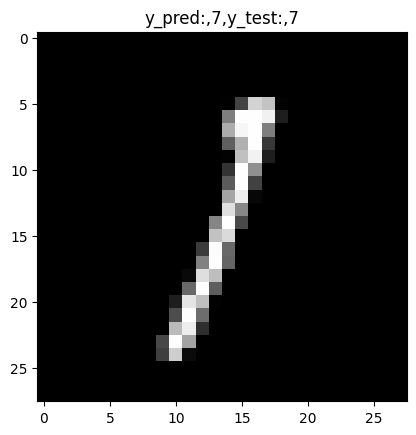

In [ ]:
plt.title(f"y_pred:,{y_pred1[4566]},y_test:,{y_test[4566]}")
plt.imshow(x_train[4566],cmap='gray')

In [ ]:
model.save("mnist_model.h5")